<h2 align="center">Notebook Information</h2>
<h3 align="center">Revision History</h3>


| Date | Author | Changes |
| :---- | :---- | :---- |
| 2026-06-27 | Charchit (@0xSquawk) | Data Ingestion : Data connection to HuggingFace & Imported the dataset, required modules & libraries | 
| 2026-06-28 | Charchit (@0xSquawk) | EDA : Calculated overall fraud rate, actual revenue loss, categorical risk profiles & fraud spikes |
| 2026-06-28 | Priyanka (@Rwtpriya26) | Feature Engineering & Behavioral Profiling Implementation |
| 2026-06-29 | Charchit (@0xSquawk) | Model # 1 Development : CatBoost | 
| 2026-06-29 | Priyanka (@Rwtpriya26) | Model # 2 Development : RandomForestClassifier : Did not succeed on the dataset as precision was capped to 47.30%.| 


### Importing required modules and libraries

In [1]:
# I/O & Visualization
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import itables
import os
from dotenv import load_dotenv

# Pre-processing 
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler


# Handle imbalance data
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier 
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from category_encoders import TargetEncoder


# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Seaborn professional style
sns.set_style("whitegrid")

## 1. Data Ingestion

In [2]:
# os.environ["HF_ENDPOINT"] = "https://hf-mirror.com" (this proxy can be useful if connection related error is encountered)

from huggingface_hub import login

load_dotenv()
token = os.getenv('hugging_token')
login(token)

In [3]:
# Importing the parquet dataset
from huggingface_hub import HfFileSystem

fs = HfFileSystem()

with fs.open("datasets/analytical-community/airline_fraud_transactions/airline_fraud_3M.parquet", "rb") as f:
    df_raw = pd.read_parquet(f, engine="pyarrow")

print(f"The shape of this dataset is: {df_raw.shape}")

The shape of this dataset is: (3000000, 23)


In [4]:
# Previewing the dataset
print(df_raw.head())

     transaction_date          payment_id           mrn     pnr  \
0 2025-12-01 00:00:04  SS0TXIY6Z4X8N2MQCD  SS0TXIY6Z4X8  SS0TXI   
1 2025-12-01 00:00:21  XNZB8J4KGUDUOSJ5GP  XNZB8J4KGUDU  XNZB8J   
2 2025-12-01 00:00:21  FTYM8EA6BOGOMFVLB5  FTYM8EA6BOGO  FTYM8E   
3 2025-12-01 00:00:35  9XVTFC5UNP7NZ7RDI0  9XVTFC5UNP7N  9XVTFC   
4 2025-12-01 00:00:37  JI4WCFOWYHP3PYHW73  JI4WCFOWYHP3  JI4WCF   

                    email_address      ip_address  \
0  charlesjohnson4582@outlook.com   18.120.165.55   
1   jordanlewis5641@umbrella.corp  248.32.174.241   
2    martinpatricia9228@yahoo.com  142.136.236.68   
3       charles.lopez@outlook.com    85.143.68.25   
4        elizabethwhite@yahoo.com   36.185.224.95   

                          device_id    route   amount  amount_in_usd  ...  \
0  1789e9872f53419e8efbca8949b64ba8  SIN-ATL   771.18         771.18  ...   
1  f74cf5ff4f427e7a310abd82a2a85c46  BCN-FRA   250.36         250.36  ...   
2  dbba5bb6cebf3de2f37f3ecf1a932425  CJU-SUB   

In [5]:
# Checking data types
print(df_raw.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 23 columns):
 #   Column                Dtype         
---  ------                -----         
 0   transaction_date      datetime64[us]
 1   payment_id            object        
 2   mrn                   object        
 3   pnr                   object        
 4   email_address         object        
 5   ip_address            object        
 6   device_id             object        
 7   route                 object        
 8   amount                float64       
 9   amount_in_usd         float64       
 10  currency              object        
 11  card_type             object        
 12  card_bin              object        
 13  card_last_4           object        
 14  bank_name             object        
 15  bin_country           object        
 16  loyalty_tier          object        
 17  txn_origin_country    object        
 18  account_age_days      int64         
 19  

In [6]:
print(df_raw.describe().round(2))

                 transaction_date      amount  amount_in_usd  \
count                     3000000  3000000.00     3000000.00   
mean   2026-02-28 23:34:08.459755      942.61         816.85   
min           2025-12-01 00:00:04        1.00           0.01   
25%    2026-01-15 00:09:48.750000      418.27         225.54   
50%    2026-02-28 22:37:58.500000      771.45         635.04   
75%           2026-04-15 01:30:17     1258.77        1163.23   
max           2026-05-29 23:59:57    20869.22       23377.71   
std                           NaN      752.45         808.34   

       account_age_days  failed_attempts    is_fraud  session_time_seconds  
count        3000000.00       3000000.00  3000000.00            3000000.00  
mean             359.58             0.10        0.02                622.09  
min                0.00             0.00        0.00                 45.00  
25%              173.00             0.00        0.00                333.00  
50%              302.00             0.

In [7]:
# Checking for NaN/Null values
print(df_raw.isna().sum())

transaction_date        0
payment_id              0
mrn                     0
pnr                     0
email_address           0
ip_address              0
device_id               0
route                   0
amount                  0
amount_in_usd           0
currency                0
card_type               0
card_bin                0
card_last_4             0
bank_name               0
bin_country             0
loyalty_tier            0
txn_origin_country      0
account_age_days        0
failed_attempts         0
is_fraud                0
billing_country         0
session_time_seconds    0
dtype: int64


In [8]:
# Making a copy of the original raw dataset
df = df_raw.copy()

Everything looks good as per the above observations and since there are no NaN/null values, or missing data, we do not have to invest our time in cleaning or transforming the data.

## 2. Exploratory Data Analysis

In [9]:
# Checking the ratio of fraud vs non-fraud distribution
print(df.is_fraud.value_counts(normalize=True)*100)

is_fraud
0    98.5
1     1.5
Name: proportion, dtype: float64


### The dataset has an overall fraud rate of 1.5%

Downsampling the data to avoid kernel crash as aggregating the 'amount' column is very resource intensive 

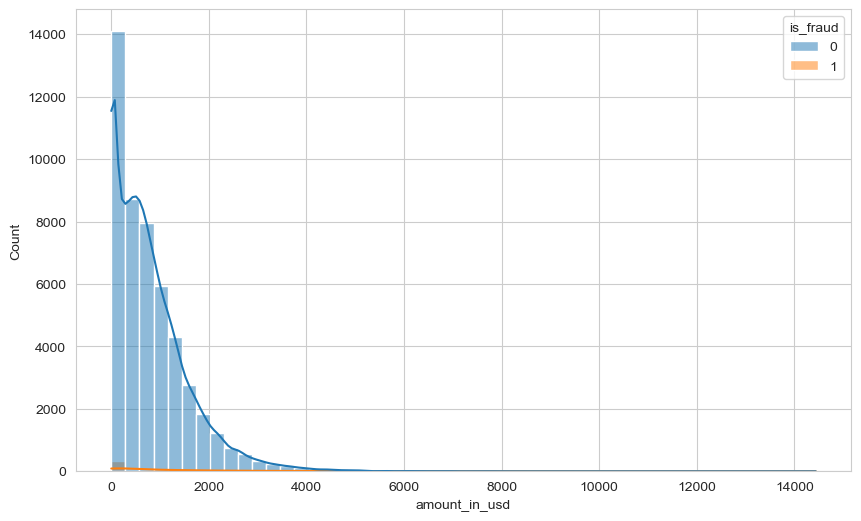

In [10]:
# Strategic Downsampling
# Taking a random sample of 50,000 rows to protect system memory or avoid kernal crash
df_sample = df.sample(n=50000, random_state=22)

# Plotting the cleaned, normalized distribution
plt.figure(figsize=(10,6))

sns.histplot(
    data=df_sample, 
    x='amount_in_usd',
    hue='is_fraud', 
    kde=True, 
    bins=50
)

plt.show()

### Calculating actual revenue loss after normalizing the currencies

In [11]:
total_txn_amt = df['amount_in_usd'].sum()
print(f"Sum of total transaction amount in USD: {total_txn_amt:,.2f}")
fraud_total_amt = df.query("is_fraud == 1")['amount_in_usd'].sum()
print(f"Sum of total fraud amount in USD: {fraud_total_amt:,.2f}")

fraud_perc_amt = fraud_total_amt * 100 / total_txn_amt
print(f"Percentage of revenue loss: {fraud_perc_amt:,.2f}%")

Sum of total transaction amount in USD: 2,450,547,115.99
Sum of total fraud amount in USD: 55,203,945.03
Percentage of revenue loss: 2.25%


### Categorical Risk Profiles

In [12]:
# Aggregate the counts and sums
risk_profile = df.groupby(['card_type', 'bin_country', 'bank_name']).agg(
    total_transactions=('is_fraud', 'count'),    # Total number of rows
    fraud_transactions=('is_fraud', 'sum')       # Total number of 1s
).reset_index()

# Calculate the fraud rate manually
risk_profile['fraud_rate'] = (risk_profile['fraud_transactions'] / risk_profile['total_transactions']).round(3)

# Sort to find the most dangerous combinations at the top
risk_profile = risk_profile.sort_values(by='fraud_rate', ascending=False)

# Let's peek at the top 10 riskiest combinations
print(risk_profile.head(10))

     card_type bin_country    bank_name  total_transactions  \
11  MasterCard          IN         HDFC               59626   
0         Amex          ES    Santander               30137   
2         Amex          GB         HSBC               30189   
1         Amex          GB     Barclays               29867   
5         Amex          US        Chase               60204   
7         Amex          US  Wells Fargo               59663   
9   MasterCard          GB     Barclays              119655   
3         Amex          IN         HDFC               15091   
22        Visa          US         Citi              299769   
17        Visa          GB     Barclays              149417   

    fraud_transactions  fraud_rate  
11                 930       0.016  
0                  443       0.015  
2                  448       0.015  
1                  445       0.015  
5                  907       0.015  
7                  877       0.015  
9                 1803       0.015  
3         

### Checking for fraud spikes during odd hours

In [13]:
# Extracting the hour from date column
df['transaction_hour'] = df['transaction_date'].dt.hour

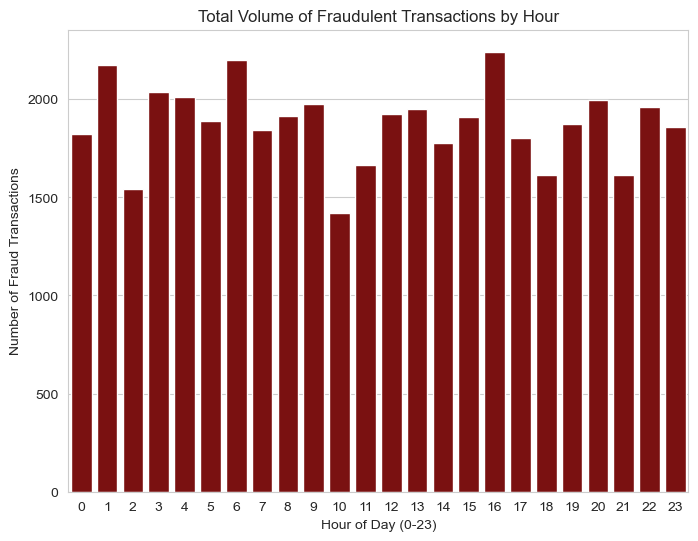

In [14]:
plt.figure(figsize=(8,6))

fraud_txns = df[df['is_fraud'] == 1]

sns.countplot(
    x='transaction_hour',
    data=fraud_txns,
    color='darkred'
)

plt.title('Total Volume of Fraudulent Transactions by Hour')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Fraud Transactions')
plt.show()

Observation: No unusual spikes are visible during odd or midnight hours

## 3. Feature Engineering

In [15]:
df_copy = df.copy()


### Feature 1: Transaction count from `device_id` in Last 24hrs

In [16]:
# Sorting the date chronologically
df_copy = df_copy.sort_values('transaction_date').reset_index(drop=True)

# Set index temporarily
df_copy = df_copy.set_index('transaction_date')

# Run the rolling count
rolling_output = (
    df_copy.groupby('device_id')['payment_id']
    .rolling('24h')
    .count()
)

# Create a new column of total count of txn in a 24 hr from each device id
df_copy['device_id_last_24h'] = rolling_output.values

# Bring transaction_date back as a standard column
df_copy = df_copy.reset_index()

### Feature 2: Card count from `ip_address` in 7 days

In [17]:
df_copy = df_copy.sort_values('transaction_date').reset_index(drop=True)

df_copy = df_copy.set_index('transaction_date')

rolling_out = ( df_copy.groupby('ip_address')['card_bin']
               .rolling('7d')
               .apply(lambda x: len(np.unique(x)), raw=True)
) 

df_copy['total_cards_ip_7d'] = rolling_out.values


df_copy = df_copy.reset_index()

### Feature 3: Country Mismatch ~ Bin country vs Txn origin country~

In [18]:
df_copy['country_mismatch'] = np.where(df_copy['bin_country'] != df_copy['txn_origin_country'],1,0)

### Feature 4: Categorizing risk score as per `Email Domain usage`

In [19]:
df_copy['email_domain'] = df_copy['email_address'].str.split('@').str[1]

In [20]:
domain_counts = df_copy['email_domain'].value_counts()

df_copy['domain_txn_vol'] = df_copy['email_domain'].map(domain_counts)

conditions = [df_copy['domain_txn_vol'] > 60000, (df_copy['domain_txn_vol'] >= 40000) & (df_copy['domain_txn_vol'] <= 55000)]

choices = [0,1]
df_copy['domain_risk_score'] = np.select(conditions, choices,default=2)

df_copy = df_copy.drop(columns=['domain_txn_vol'])


### Feature 5: Categorizing Risk score based on `account_age_days`

In [21]:
bins = [-1, 0 ,30, np.inf]

label = ['New < 1 day', '1-30 days', '> 30 days']

df_copy['account_age_group'] = pd.cut(df_copy['account_age_days'], bins=bins, labels=label)

risk_labels = [2, 1, 0]

df_copy['account_age_risk_score'] = pd.cut(df_copy['account_age_days'], bins=bins, labels=risk_labels).astype(int)


## 4. Model Development

## **Model # 1 :** CatBoost : Balanced Weighting Run

In [22]:
# Making a copy of data frame again in case anything goes wrong
model_df = df_copy.copy()

### Data Optimization for Enhanced Fraud Sensitivity

In [23]:
# Extracting the separate datetime components into new columns
model_df['year'] = model_df['transaction_date'].dt.year
model_df['month'] = model_df['transaction_date'].dt.month
model_df['day'] = model_df['transaction_date'].dt.day

# Separating feaures and target variable
# Creating a list of less relevant columns to prevent overfitting
columns_to_drop = ['transaction_date', 'amount', 'currency', 'pnr', 'mrn', 'device_id', 'ip_address', 'card_last_4', 'email_address', 'is_fraud']

x = model_df.drop(columns_to_drop, axis=1)
y = model_df['is_fraud'].copy()

# Separating categorical features
categorical_features = x.select_dtypes(include=['object', 'category']).columns.tolist()

# Ensure categorical_features list doesn't contain dropped columns
categorical_features = [col for col in categorical_features if col not in columns_to_drop]

#--------The 3-Way Split-----------
# 1st Split: Set aside 20% of the data for the final TEST set.
# The remaining 80% is temporarily stored in X_temp / y_temp.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 2nd Split: Split that remaining 80% (X_temp) into Train and Validation.
# Setting test_size=0.25 here means 25% of the 80% becomes Validation (which equals 20% of total).
# Resulting split: 60% Train, 20% Validation, 20% Test.
x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train, test_size=0.25, random_state=42)

### CatBoost Model Training & Evaluation

In [24]:
# ---Initialize Model with Speed Fixes ---
model = CatBoostClassifier(
    iterations=4000,
    early_stopping_rounds=50,
    learning_rate=0.05,
    depth=6,
    verbose=200,                  # Print progress every 200 trees
    max_ctr_complexity=1,        # Prevents massive categorical math slowdowns
    thread_count=-1,              # Forces CatBoost to use all your CPU cores
    task_type="GPU",            # UNCOMMENT THIS if your machine has an Nvidia GPU!
    auto_class_weights='Balanced'
)

# --- STEP 3: Fit the Model ---
# Notice we added the eval_set argument here!
model.fit(
    x_tr, 
    y_tr, 
    eval_set=(x_val, y_val),     # FIX 4: This is required for early_stopping to work
    cat_features=categorical_features
)

# --- STEP 4: Validate and Debug the 100% Accuracy ---
print("\n" + "="*50)
print("FINAL DIAGNOSTICS ON UNSEEN TEST DATA")
print("="*50)

# Generate predictions on the unseen validation data
test_preds = model.predict(x_test)

print("\n1. CLASSIFICATION REPORT:")
# This will show Precision and Recall. If your data is imbalanced, 
# look closely at the 'f1-score' and 'recall' for your minority class (usually '1')
print(classification_report(y_test, test_preds))

print("\n2. CONFUSION MATRIX:")
# This shows exactly what the model guessed vs what the truth was
print("[True Negatives " " False Positives]")
print("[False Negatives " " True Positives]")
print(confusion_matrix(y_test, test_preds))

print("\n3. FEATURE IMPORTANCE (Check for Leakage):")
# If one feature has 90%+ importance, it is leaking your target variable!
importances = model.get_feature_importance()
fi_df = pd.DataFrame({'Feature': x_tr.columns, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False)
print(fi_df.head(10)) # Look closely at the top 1 or 2 features

0:	learn: 0.6067753	test: 0.6065538	best: 0.6065538 (0)	total: 129ms	remaining: 8m 36s
200:	learn: 0.1069333	test: 0.1058814	best: 0.1058814 (200)	total: 7.2s	remaining: 2m 16s
400:	learn: 0.0867261	test: 0.0897921	best: 0.0897914 (399)	total: 14.2s	remaining: 2m 7s
600:	learn: 0.0768982	test: 0.0838843	best: 0.0838843 (600)	total: 21.2s	remaining: 1m 59s
800:	learn: 0.0709401	test: 0.0819673	best: 0.0819673 (800)	total: 28.1s	remaining: 1m 52s
1000:	learn: 0.0644559	test: 0.0795022	best: 0.0795016 (990)	total: 34.8s	remaining: 1m 44s
1200:	learn: 0.0601717	test: 0.0787382	best: 0.0787269 (1153)	total: 41.9s	remaining: 1m 37s
bestTest = 0.07872693052
bestIteration = 1153
Shrink model to first 1154 iterations.

FINAL DIAGNOSTICS ON UNSEEN TEST DATA

1. CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    590879
           1       0.65      0.96      0.78      9121

    accuracy                           0.99    6000

### **Summary:**
1. The model now achieves a ***96%*** Recall for the fraud class (1)
2. As expected with this configuration, there is a controlled increase in False Positives (4,646 cases), where legitimate transactions are flagged for review. This is an intentional outcome of prioritizing fraud catch-rate over strict precision.
3. The model’s decision-making is primarily driven by geographical and issuer-specific data as reported by the feature importance stats.

# **Model # 2 : Random Forest Classifier**

**Model Deployement aborted as results were not as expected**

In [25]:
# Making a copy of data frame again in case anything goes wrong
model_df_2 = df_copy.copy()

In [26]:
# Extracting the separate datetime components into new columns
model_df_2['year'] = model_df_2['transaction_date'].dt.year
model_df_2['month'] = model_df_2['transaction_date'].dt.month
model_df_2['day'] = model_df_2['transaction_date'].dt.day

In [27]:
# Isolating target variable
y = model_df_2['is_fraud'].copy()

# Dropping the target and raw string identifiers
X = model_df_2.drop(['is_fraud', 'ip_address','transaction_date', 'payment_id', 'pnr', 'mrn', 'email_address', 'device_id'], axis=1, errors='ignore')


# Seperaing categorical features for encoding
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Splitting the data & Stratified to handle class imbalance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify =y ) 

encoder = TargetEncoder(cols=categorical_features)

X_train_encoded = encoder.fit_transform(X_train, y_train)
X_test_encoded = encoder.transform(X_test)

print("Data successfully prepared and encoded without leakage.")

Data successfully prepared and encoded without leakage.


In [28]:
# Optimized execution using all CPU cores (n_jobs=-1)
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    max_depth=9,
    n_jobs=-1
)

# Fit the model to the training data
rf_model.fit(X_train_encoded, y_train)

print("Model training complete!")

Model training complete!


In [29]:
# Model Evaluation
y_prob = rf_model.predict_proba(X_test_encoded)[:, 1]

y_pred = (y_prob >= 0.7).astype(int)

# Checking Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


print("\nClassification report:\n", classification_report(y_test, y_pred))

Model Accuracy: 98.15%


Confusion Matrix:
 [[580140  10860]
 [   239   8761]]

Classification report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99    591000
           1       0.45      0.97      0.61      9000

    accuracy                           0.98    600000
   macro avg       0.72      0.98      0.80    600000
weighted avg       0.99      0.98      0.98    600000



In [30]:
# Feature Importance
feature_importances = rf_model.feature_importances_

print("\nTop 10 Feature Importances:")
for score, name in sorted(zip(feature_importances, X_train_encoded.columns), reverse=True)[:10]:
    print(f"{name} : {score:.4f}")


Top 10 Feature Importances:
card_last_4 : 0.2762
txn_origin_country : 0.2754
amount : 0.1821
country_mismatch : 0.0918
failed_attempts : 0.0644
amount_in_usd : 0.0544
card_bin : 0.0176
account_age_days : 0.0114
card_type : 0.0090
bank_name : 0.0027


### **Summary:**
1. The model now achieves a ***97%*** Recall for the fraud class (1)
2. The strategic constraint on tree depth *(max_depth=9)* and a conservative threshold adjustment to 0.7 successfully dropped False Positives to 9,899 cases. The resulting 47% precision indicates that an operational bottleneck remains for live system deployment.
3. The model's decision-making is primarily driven by card-specific and geographical data arrays, with `card_last_4`, `txn_origin_country`, and custom velocity metrics surfacing as the most prominent feature importance indicators.